## 1.Análisis del problema

**Sector:** retail farmacéutico en Europa.
**Problema del cliente:** quiere saber qué vender, dónde y si compensa promocionar.

1. ¿Qué países y categorías generan más ingresos y mejor margen?
2. ¿Cómo evolucionan las ventas mes a mes y hay estacionalidad?
3. ¿Las promociones aumentan las unidades vendidas o solo reducen el margen?

## 2. Adquisición de los datos

- **Fuente:** European Pharmacy Sales (Kaggle), dataset sintético con licencia MIT.
- **Formato:** un único fichero Excel (`Pharmacy_data.xlsx`) con 4 hojas en esquema de estrella.
- **Tablas:** FactSales (hechos, 62.139 filas) y tres dimensiones: DimDate (731), DimPharmacy (120), DimProduct (220).
- **Herramienta de carga:** pandas (`read_excel`), por ser datos tabulares que caben en memoria.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
Datos = pd.read_excel("../Data/Pharmacy_data.xlsx", sheet_name=None)
for nombre, df in Datos.items():
    print(nombre, df.shape)

FactSales (62139, 9)
DimDate (731, 7)
DimPharmacy (120, 10)
DimProduct (220, 11)


In [44]:
fact = Datos["FactSales"]
fecha = Datos["DimDate"]
farmacia = Datos["DimPharmacy"]
producto = Datos["DimProduct"]

## 3. Exploración de los datos

### 3.1 Resumen por hoja (muestra, variables, tipos, tamaño)

In [70]:
for nombre, df in Datos.items():
    print(f"\n=== {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas ===")
    display(df.head(3))
    display(df.dtypes.to_frame("tipo").T)


=== FactSales: 62139 filas x 9 columnas ===


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag
tipo,str,int64,str,str,int64,float64,float64,float64,str



=== DimDate: 731 filas x 7 columnas ===


,DateKey,Date,Year,Quarter,MonthNumber,MonthName,YearMonth
0,20240101,2024-01-01,2024,1,1,January,2024-01
1,20240102,2024-01-02,2024,1,1,January,2024-01
2,20240103,2024-01-03,2024,1,1,January,2024-01


...

,PharmacyID,PharmacyName,Country,Region,City,PharmacyType,OpenDate,StoreSizeBand,Latitude,Longitude
0,PH0001,Naples HealthPoint #001,Italy,Campania,Naples,Suburban,2025-04-03,M,40.839137,14.279288
1,PH0002,Innsbruck HealthPoint #002,Austria,Tyrol,Innsbruck,Urban,2011-12-21,M,47.254915,11.410136
2,PH0003,Barcelona HealthPoint #003,Spain,Catalonia,Barcelona,Urban,2025-04-20,M,41.386090,2.170678


,PharmacyID,PharmacyName,Country,Region,City,PharmacyType,OpenDate,StoreSizeBand,Latitude,Longitude
tipo,str,str,str,str,str,str,str,str,float64,float64



=== DimProduct: 220 filas x 11 columnas ===


,ProductID,ProductName,Category,Brand,IsGeneric,PackSize,ListPriceEUR,StandardCostEUR,LaunchDate,IsDiscontinued,DiscontinuedDate
0,PR0001,CareEquip Glucose Test Strips Compact,Medical Devices,CareEquip,No,1 unit,10.14,8.19,2018-04-09,No,NaN
1,PR0002,Medica Nasal Spray 100 mg,OTC,Medica,No,200 ml,7.03,5.52,2015-08-21,No,NaN
2,PR0003,VitaCare Vitamin C 100 mg,OTC,VitaCare,No,30 tablets,13.42,10.69,2022-11-22,No,NaN


,ProductID,ProductName,Category,Brand,IsGeneric,PackSize,ListPriceEUR,StandardCostEUR,LaunchDate,IsDiscontinued,DiscontinuedDate
tipo,str,str,str,str,str,str,float64,float64,str,str,str


## 3.2 Variables numéricas

,UnitsSold,RevenueEUR,CostEUR,MarginEUR
count,62139.00,62139.00,62139.00,62139.00
mean,7.17,138.95,99.98,38.96
std,4.87,124.57,93.61,33.97
min,1.00,1.61,1.10,0.44
25%,3.00,55.25,39.33,15.14
50%,6.00,102.75,72.22,28.99
75%,10.00,181.35,128.68,51.99
max,25.00,1036.28,834.42,295.31


Asimetría:
 UnitsSold     1.02
RevenueEUR    2.17
CostEUR       2.40
MarginEUR     1.89
dtype: float64


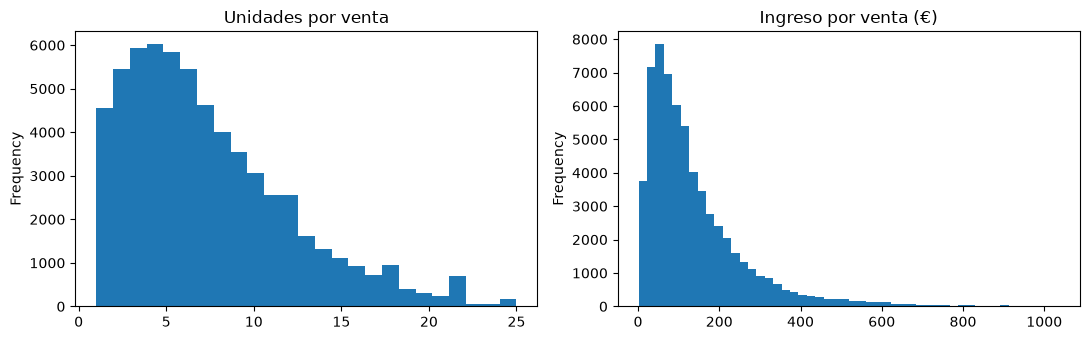

In [ ]:
fact = Datos["FactSales"]
num = ["UnitsSold", "RevenueEUR", "CostEUR", "MarginEUR"]

display(fact[num].describe().round(2))
print("Asimetría:\n", fact[num].skew().round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
fact["UnitsSold"].plot.hist(bins=25, ax=ax[0], title="Unidades por venta")
fact["RevenueEUR"].plot.hist(bins=50, ax=ax[1], title="Ingreso por venta (€)")
plt.tight_layout(); plt.show()

# Precios de catálogo
display(Datos["DimProduct"][["ListPriceEUR", "StandardCostEUR"]].describe().round(2))

## 3.3 Variables categóricas

In [50]:
farm = Datos["DimPharmacy"]
prod = Datos["DimProduct"]

for col in ["Country", "PharmacyType", "StoreSizeBand"]:
    display(farm[col].value_counts().to_frame("farmacias"))

for col in ["Category", "IsGeneric", "IsDiscontinued"]:
    display(prod[col].value_counts().to_frame("productos"))

display(fact["PromoFlag"].value_counts(normalize=True).round(3).to_frame("proporción"))

,farmacias
Country,
Germany,22
France,20
Italy,18
Belgium,14
Poland,13
Spain,12
Netherlands,11
Austria,10


,farmacias
PharmacyType,
Urban,50
Suburban,47
Rural,23


,farmacias
StoreSizeBand,
M,53
S,42
L,25


,productos
Category,
OTC,61
Personal Care,47
Prescription,47
Wellness,41
Medical Devices,24


,productos
IsGeneric,
No,187
Yes,33


,productos
IsDiscontinued,
No,185
Yes,35


,proporción
PromoFlag,
No,0.88
Yes,0.12


In [33]:
for nombre, df in Datos.items():
    print(f"\n=== {nombre} ===")
    print("Nulos por columna:\n", df.isna().sum()[df.isna().sum() > 0])
    print("Filas duplicadas:", df.duplicated().sum())


=== FactSales ===
Nulos por columna:
 Series([], dtype: int64)
Filas duplicadas: 0

=== DimDate ===
Nulos por columna:
 Series([], dtype: int64)
Filas duplicadas: 0

=== DimPharmacy ===
Nulos por columna:
 Series([], dtype: int64)
Filas duplicadas: 0

=== DimProduct ===
Nulos por columna:
 DiscontinuedDate    185
dtype: int64
Filas duplicadas: 0


In [35]:
print(set(fact.columns) & set(fecha.columns))
print(set(fact.columns) & set(farmacia.columns))
print(set(fact.columns) & set(producto.columns))

{'DateKey'}
{'PharmacyID'}
{'ProductID'}


Unir las 4 tablas

In [37]:

data = (
    fact
    .merge(fecha, on="DateKey", how="left", validate="many_to_one")
    .merge(farmacia, on="PharmacyID", how="left", validate="many_to_one")
    .merge(producto, on="ProductID", how="left", validate="many_to_one")
)

In [38]:
data["Fecha"] = pd.to_datetime(data["DateKey"].astype(str), format="%Y%m%d")
data["OpenDate"] = pd.to_datetime(data["OpenDate"])
data["DiscontinuedDate"] = pd.to_datetime(data["DiscontinuedDate"])

antes_apertura = data[data["Fecha"] < data["OpenDate"]]
tras_descatalogar = data[data["Fecha"] > data["DiscontinuedDate"]]

print("Ventas antes de abrir la farmacia:", len(antes_apertura))
print("Ventas de productos ya descatalogados:", len(tras_descatalogar))

Ventas antes de abrir la farmacia: 0
Ventas de productos ya descatalogados: 0


## 4. Análisis y visualización

### **Pregunta 1: países y categorías**

In [39]:
p1_pais = (
    data.groupby("Country")
    .agg(ingresos=("RevenueEUR", "sum"),
         margen=("MarginEUR", "sum"),
         farmacias=("PharmacyID", "nunique"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100,
            ingresos_por_farmacia=lambda d: d["ingresos"] / d["farmacias"],
            margen_por_farmacia=lambda d: d["margen"] / d["farmacias"])
    .sort_values("ingresos", ascending=False)
)
p1_pais.round(1)

,ingresos,margen,farmacias,margen_pct,ingresos_por_farmacia,margen_por_farmacia
Country,,,,,,
Germany,1567634.0,439238.0,22,28.0,71256.1,19965.4
France,1406811.7,393705.5,20,28.0,70340.6,19685.3
Italy,1332155.5,374344.2,18,28.1,74008.6,20796.9
Belgium,1246510.8,351005.5,14,28.2,89036.5,25071.8
Netherlands,947748.2,265194.6,11,28.0,86158.9,24108.6
Spain,735600.2,204778.0,12,27.8,61300.0,17064.8
Poland,714235.7,200443.2,13,28.1,54941.2,15418.7
Austria,683281.2,192432.0,10,28.2,68328.1,19243.2


In [ ]:
meses_totales = data["YearMonth"].nunique()  

ph = data.groupby(["Country", "PharmacyID"]).agg(meses=("YearMonth", "nunique")).reset_index()

p1_mes = (
    data.groupby("Country")
        .agg(ingresos=("RevenueEUR", "sum"),
             margen=("MarginEUR", "sum"),
             ventas=("SalesID", "count"))
        .join(ph.groupby("Country").agg(
            farmacias=("PharmacyID", "count"),
            meses_farmacia=("meses", "sum"),
            farmacias_nuevas=("meses", lambda s: (s < meses_totales).sum())))
        .assign(ticket_medio=lambda d: d["ingresos"] / d["ventas"],
                ventas_por_farmacia_mes=lambda d: d["ventas"] / d["meses_farmacia"],
                ingreso_por_farmacia_mes=lambda d: d["ingresos"] / d["meses_farmacia"],
                margen_por_farmacia_mes=lambda d: d["margen"] / d["meses_farmacia"])
        .sort_values("ingreso_por_farmacia_mes", ascending=False)
)
p1_mes.round(1)

,ingresos,margen,ventas,farmacias,meses_farmacia,farmacias_nuevas,ticket_medio,ventas_por_farmacia_mes,ingreso_por_farmacia_mes,margen_por_farmacia_mes
Country,,,,,,,,,,
Belgium,1246510.8,351005.5,8280,14,334,1,150.5,24.8,3732.1,1050.9
Netherlands,947748.2,265194.6,6138,11,258,1,154.4,23.8,3673.4,1027.9
Austria,683281.2,192432.0,4693,10,202,2,145.6,23.2,3382.6,952.6
Italy,1332155.5,374344.2,9872,18,399,3,134.9,24.7,3338.7,938.2
Germany,1567634.0,439238.0,10628,22,509,2,147.5,20.9,3079.8,862.9
France,1406811.7,393705.5,10187,20,480,0,138.1,21.2,2930.9,820.2
Spain,735600.2,204778.0,5700,12,259,2,129.1,22.0,2840.2,790.6
Poland,714235.7,200443.2,6641,13,312,0,107.5,21.3,2289.2,642.4


In [40]:
p1_cat = (
    data.groupby("Category")
    .agg(ingresos=("RevenueEUR", "sum"), margen=("MarginEUR", "sum"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100)
    .sort_values("margen", ascending=False)
)
p1_cat.round(1)

,ingresos,margen,margen_pct
Category,,,
Prescription,2797015.8,613166.4,21.9
Wellness,1712456.9,575117.0,33.6
OTC,1797329.6,528166.0,29.4
Personal Care,1454603.2,486875.2,33.5
Medical Devices,872572.0,217816.5,25.0


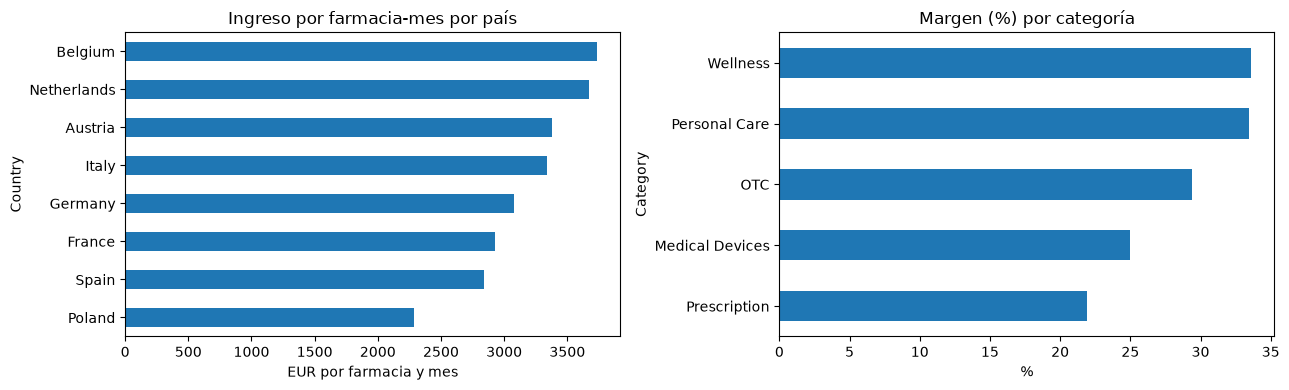

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
p1_mes["ingreso_por_farmacia_mes"].sort_values().plot.barh(ax=ax[0], title="Ingreso por farmacia-mes por país")
p1_cat["margen_pct"].sort_values().plot.barh(ax=ax[1], title="Margen (%) por categoría")
ax[0].set_xlabel("EUR por farmacia y mes")
ax[1].set_xlabel("%")
plt.tight_layout()
plt.show()

### Conclusión 1: Países y categorías

**Países.**
- El margen porcentual apenas varía entre países (27,8 % - 28,2 %), así que las diferencias vienen del volumen por farmacia y no de la rentabilidad de cada venta.
- Corrigiendo por los meses de actividad de cada farmacia, **Bélgica** (3.732 € de ingreso por farmacia-mes) y **Países Bajos** (3.673 €) lideran. **Polonia** es última (2.289 €), un 39 % por debajo de Bélgica, y no tiene ninguna farmacia abierta en 2025, así que no es un efecto de aperturas recientes.
- **Alemania** lidera en margen total (439 k€) solo por tener más farmacias (22); por farmacia-mes queda en la mitad baja.
- La brecha se explica sobre todo por el **ticket medio** (de 107,5 € en Polonia a 154,4 € en Países Bajos) y, en menor medida, por las ventas por farmacia (de 20,9 a 24,8 al mes). El mix de categorías es casi idéntico en todos los países, así que no depende de qué se vende.

**Categorías.**
- **Prescription** aporta el mayor margen en euros (613 k€), pero con el margen % más bajo (21,9 %): es el 32,4 % de los ingresos y el 25,3 % del margen.
- **Wellness** (33,6 %) y **Personal Care** (33,5 %) tienen los mejores márgenes y suman el 36,6 % de los ingresos pero el 43,9 % del margen.

In [16]:
print(pd.crosstab(data["Country"], data["Category"], values=data["RevenueEUR"],
                  aggfunc="sum", normalize="index").round(2))

Category     Medical Devices   OTC  Personal Care  Prescription  Wellness
Country                                                                  
Austria                 0.09  0.21           0.16          0.33      0.21
Belgium                 0.10  0.21           0.18          0.31      0.19
France                  0.10  0.21           0.16          0.33      0.20
Germany                 0.10  0.21           0.17          0.33      0.20
Italy                   0.11  0.21           0.17          0.32      0.20
Netherlands             0.10  0.21           0.17          0.33      0.19
Poland                  0.10  0.21           0.16          0.32      0.20
Spain                   0.10  0.20           0.16          0.34      0.20


,% ingresos,% margen
Category,,
Prescription,32.4,25.3
Wellness,19.8,23.8
OTC,20.8,21.8
Personal Care,16.8,20.1
Medical Devices,10.1,9.0


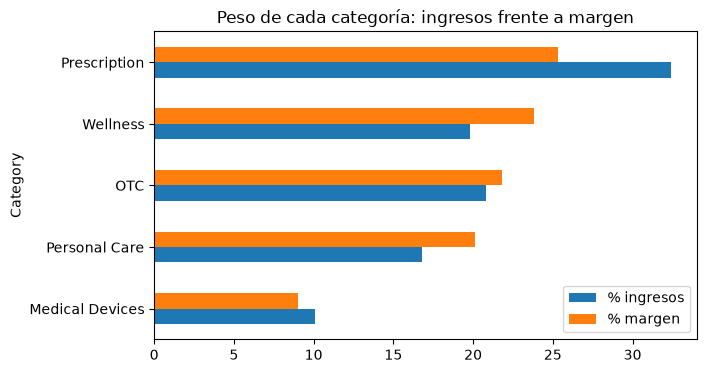

In [53]:
cuota = pd.DataFrame({
    "% ingresos": p1_cat["ingresos"] / p1_cat["ingresos"].sum() * 100,
    "% margen":   p1_cat["margen"]   / p1_cat["margen"].sum() * 100,
}).round(1)
display(cuota)
cuota.sort_values("% margen").plot.barh(figsize=(7, 4),
                                        title="Peso de cada categoría: ingresos frente a margen")
plt.show()

### **Pregunta 2 :¿Cómo evolucionan las ventas mes a mes y hay estacionalidad?**

In [62]:
p2 = data.groupby("YearMonth")["RevenueEUR"].sum().reset_index()
p2["Año"] = p2["YearMonth"].str[:4]
p2["Mes"] = p2["YearMonth"].str[5:7]
p2_tabla = p2.pivot(index="Mes", columns="Año", values="RevenueEUR")

p2_tabla["variación_%"] = (p2_tabla["2025"] / p2_tabla["2024"] - 1) * 100
display(p2_tabla.round(1))
print(p2_tabla[["2024", "2025"]].sum().round(0))

Año,2024,2025,variación_%
Mes,,,
01,348141.2,345071.0,-0.9
02,327319.2,329089.0,0.5
03,346366.7,354624.0,2.4
04,330369.3,355072.7,7.5
05,357867.0,392674.3,9.7
06,342538.3,379229.0,10.7
07,388334.1,380506.7,-2.0
08,373987.8,367548.0,-1.7
09,357304.8,373700.9,4.6


Año
2024    4223414.0
2025    4410563.0
dtype: float64


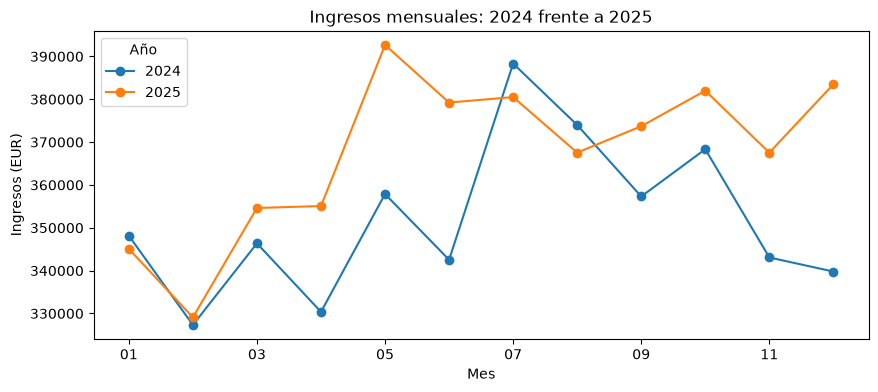

In [65]:
p2_tabla[["2024", "2025"]].plot(marker="o", figsize=(10, 4),
         title="Ingresos mensuales: 2024 frente a 2025")
plt.ylabel("Ingresos (EUR)")
plt.xlabel("Mes")
plt.show()

### Conclusión 2: Evolución mensual y estacionalidad

- Los ingresos pasan de 4,22 M€ en 2024 a 4,41 M€ en 2025 (**+4,4 %**). 2025 supera a 2024 en 9 de los 12 meses; solo bajan enero (-0,9 %), julio (-2,0 %) y agosto (-1,7 %).
- El crecimiento se concentra a partir de abril: de enero a marzo la variación es de -0,9 % a +2,4 %, y de abril a diciembre llega a +12,9 % en diciembre y +10,7 % en junio.
- **No hay una estacionalidad estable entre años.** El mes más alto cambia (julio en 2024, con 388 k€; mayo en 2025, con 393 k€) y solo febrero es el más bajo en ambos años, en parte por tener menos días.
- **Recomendación:** no planificar el stock con un patrón estacional fijo, y comprobar si el aumento a partir de abril se debe a farmacias nuevas o a más ventas por farmacia antes de usar el +4,4 % como previsión.

### **Pregunta 3: promociones**

In [19]:
p3 = (
    data.groupby("PromoFlag")
    .agg(ventas=("SalesID", "count"),
         unidades_medias=("UnitsSold", "mean"),
         ingreso_medio=("RevenueEUR", "mean"),
         ingresos=("RevenueEUR", "sum"),
         margen=("MarginEUR", "sum"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100)
)
p3.round(2)

,ventas,unidades_medias,ingreso_medio,ingresos,margen,margen_pct
PromoFlag,,,,,,
No,54708,7.19,141.16,7722676.25,2239573.20,29.00
Yes,7431,7.02,122.64,911301.06,181567.87,19.92


Y el mismo calculo pero por categorias

In [66]:
p3_cat = (
    data.groupby(["Category", "PromoFlag"])
    .agg(unidades_medias=("UnitsSold", "mean"),
         ingresos=("RevenueEUR", "sum"),
         margen=("MarginEUR", "sum"))
    .assign(margen_pct=lambda d: d["margen"] / d["ingresos"] * 100)
    .round(2)
)
p3_cat

unidades_medias    ingresos     margen  margen_pct
Category        PromoFlag                                                    
Medical Devices No                    2.30   779619.95  202025.43       25.91
                Yes                   2.26    92952.02   15791.04       16.99
OTC             No                    9.17  1610572.58  487899.45       30.29
                Yes                   9.03   186756.97   40266.58       21.56
Personal Care   No                    9.22  1314042.81  450445.02       34.28
                Yes                   8.77   140560.34   36430.16       25.92
Prescription    No                    4.82  2484255.43  570116.78       22.95
                Yes                   4.84   312760.33   43049.61       13.76
Wellness        No                    7.18  1534185.48  529086.52       34.49
                Yes                   7.07   178271.40   46030.48       25.82

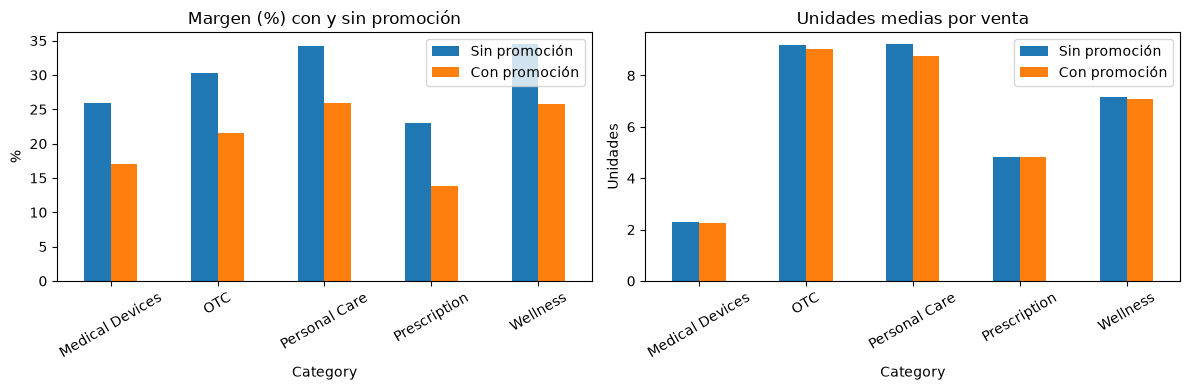

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

p3_cat["margen_pct"].unstack("PromoFlag")[["No", "Yes"]].plot.bar(ax=ax[0], rot=30)
ax[0].set_title("Margen (%) con y sin promoción")
ax[0].set_ylabel("%")
ax[0].legend(["Sin promoción", "Con promoción"])

p3_cat["unidades_medias"].unstack("PromoFlag")[["No", "Yes"]].plot.bar(ax=ax[1], rot=30)
ax[1].set_title("Unidades medias por venta")
ax[1].set_ylabel("Unidades")
ax[1].legend(["Sin promoción", "Con promoción"])

plt.tight_layout()
plt.show()

In [68]:
p3["ingreso_por_unidad"] = p3["ingresos"] / (p3["ventas"] * p3["unidades_medias"])
p3["coste_por_unidad"] = (p3["ingresos"] - p3["margen"]) / (p3["ventas"] * p3["unidades_medias"])
p3[["ingreso_por_unidad", "coste_por_unidad"]].round(2)

,ingreso_por_unidad,coste_por_unidad
PromoFlag,,
No,19.62,13.93
Yes,17.46,13.98


### Conclusión 3: Efecto de las promociones

- Las promociones **no aumentan las unidades por venta** (7,02 frente a 7,19 sin promoción) y **reducen el margen del 29,0 % al 19,9 %**, con una caída de entre 8,4 y 9,2 puntos en todas las categorías.
- El mecanismo es un descuento de precio: el ingreso por unidad baja un 11 % (de 19,62 € a 17,46 €) mientras el coste por unidad no cambia (13,93 € frente a 13,98 €). El margen por unidad cae así un 39 % (de 5,69 € a 3,48 €).
- Las ventas en promoción son el 12,0 % del total pero aportan solo el 7,5 % del margen. En **Prescription** el margen en promoción baja al 13,8 %, el más bajo de todas las categorías.
- **Recomendación:** reducir o rediseñar las promociones, empezando por Prescription. Para compensar la pérdida de margen por unidad, cada promoción tendría que vender un 63 % más de unidades, y los datos no muestran ningún aumento. Como solo se han medido unidades por venta y no el número de ventas, conviene confirmar con datos de tráfico si atraen más clientes antes de eliminarlas.